In [2]:
import numpy as np
import copy
from scipy.io import loadmat

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.animation as animation
from pathlib import Path
from nanopinv.physics import travel_time_points
import skfmm

import gstools as gs
from gstools import covmodel

from tqdm.auto import trange, tqdm
from nanopinv.prior import CholeskyPrior

import seaborn as sns


# # ignore plot warnings in gstools
# import warnings
# warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load dataset
M = loadmat("AM13_data.mat")
N_data, N_dim = M["S"].shape
sources = M["S"]  # Shape: (N_data, N_dim)
receivers = M["R"]  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, "Sources and receivers must have the same shape."

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(data_obs)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\field\generator.py:237: UserWarning: gstools.RandMeth: **kwargs are ignored
  warnings.warn("gstools.RandMeth: **kwargs are ignored")


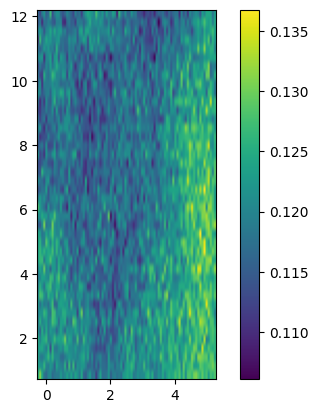

In [ ]:
# Set up prior
# Set up grid
dx = 0.135
x = np.arange(-2 * dx, 5 + 2 * dx, dx)
y = np.arange(1 - 2 * dx, 12 + 2 * dx, dx)


m0 = 0.12
C_m = covmodel.Spherical(dim=2, var=0.00003, len_scale=7)  # '0.00003 Sph(7)'

# Model parameters: Velocity field


srf = gs.SRF(C_m, mean=m0, generator_kwargs={"mode_no": 50})
samples = srf.structured((x, y))
# samples = srf((r[:, 0], r[:, 1]))

plt.imshow(samples, extent=(x[0], x[-1], y[0], y[-1]), origin='lower', cmap=cm.viridis)
plt.colorbar()

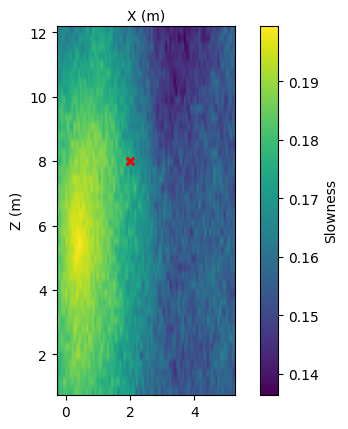

In [5]:
# Generate movie similar to the one in the example notebook from `pinv`

fig = plt.figure(0)
ax = plt.gca()
ax.set_aspect('equal')
ax.xaxis.set_label_position('top')
ax.set_xlabel('X (m)')
ax.set_ylabel('Z (m)')

frames = []  # for storing the generated images

cond_pos = [(2, 8), (2.1, 8)]
cond_val = [0.2, 0.1]

krige = gs.krige.Ordinary(C_m, cond_pos=cond_pos, cond_val=cond_val)
cond_srf = gs.CondSRF(krige)

for i in range(20):
    realisation = cond_srf.structured((x, y), seed=i)
    im = ax.imshow(
        realisation,
        extent=(x[0], x[-1], y[0], y[-1]),
        origin='lower',
        cmap=cm.viridis,
    )
    ax.scatter(cond_pos[0][0], cond_pos[0][1], color='red', alpha=0.3, marker='x', s=25, label='Conditioned Point')
    frames.append([im])

fig.colorbar(frames[0][0], ax=ax, label='Slowness')

ani = animation.ArtistAnimation(
    fig,
    frames,
    interval=100,
    blit=True,
    repeat_delay=1000,
    )

import matplotlib as mpl
import imageio_ffmpeg
mpl.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
video = ani.to_html5_video()
from IPython.display import HTML
HTML(video)

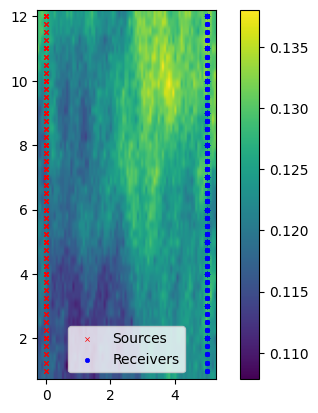

In [6]:
# Forward model
# def travel_time(m):

plt.figure()

realisation = srf.structured((x, y), seed=0)
plt.imshow(realisation, extent=(x[0], x[-1], y[0], y[-1]), origin='lower', cmap=cm.viridis)
plt.colorbar()

plt.scatter(sources[:, 0], sources[:, 1], c='red', marker="x", s=10, lw=0.5, label='Sources')
plt.scatter(receivers[:, 0], receivers[:, 1], c='blue', marker="o", s=10, lw=0.5, label='Receivers')

plt.legend()



In [7]:
realisation.shape

(42, 86)

In [8]:
np.unique(sources, axis=0)

array([[ 0.  ,  1.  ],
       [ 0.  ,  1.25],
       [ 0.  ,  1.5 ],
       [ 0.  ,  1.75],
       [ 0.  ,  2.  ],
       [ 0.  ,  2.25],
       [ 0.  ,  2.5 ],
       [ 0.  ,  2.75],
       [ 0.  ,  3.  ],
       [ 0.  ,  3.25],
       [ 0.  ,  3.5 ],
       [ 0.  ,  3.75],
       [ 0.  ,  4.  ],
       [ 0.  ,  4.25],
       [ 0.  ,  4.5 ],
       [ 0.  ,  4.75],
       [ 0.  ,  5.  ],
       [ 0.  ,  5.25],
       [ 0.  ,  5.5 ],
       [ 0.  ,  5.75],
       [ 0.  ,  6.  ],
       [ 0.  ,  6.25],
       [ 0.  ,  6.5 ],
       [ 0.  ,  6.75],
       [ 0.  ,  7.  ],
       [ 0.  ,  7.25],
       [ 0.  ,  7.5 ],
       [ 0.  ,  7.75],
       [ 0.  ,  8.  ],
       [ 0.  ,  8.25],
       [ 0.  ,  8.5 ],
       [ 0.  ,  8.75],
       [ 0.  ,  9.  ],
       [ 0.  ,  9.25],
       [ 0.  ,  9.5 ],
       [ 0.  ,  9.75],
       [ 0.  , 10.  ],
       [ 0.  , 10.25],
       [ 0.  , 10.5 ],
       [ 0.  , 10.75],
       [ 0.  , 11.  ],
       [ 0.  , 11.25],
       [ 0.  , 11.5 ],
       [ 0.

In [9]:
sources

array([[ 0.  ,  2.  ],
       [ 0.  ,  2.  ],
       [ 0.  ,  2.  ],
       ...,
       [ 0.  , 11.5 ],
       [ 0.  , 11.75],
       [ 0.  , 12.  ]], shape=(702, 2))

In [10]:


receivers
travel_times = travel_time_points([x, y], speeds = realisation, source=sources[55], receivers=receivers, window=1)

def forward_model(m):
    # Sources and receivers are not unique, but rather set up as a grid
    # For simplicity, we iterate over all sources and compute the receivers for each source, then concatenate appropriate
    travel_times = np.empty(shape=(N_data,))

    unique_sources, inverse_indices = np.unique(sources, axis=0, return_inverse=True)
    for i, u_src in enumerate(unique_sources):
        mask = (inverse_indices == i)
        associated_receivers = receivers[mask]
        travel_times[mask] = travel_time_points([x, y], speeds=m, source=u_src, receivers=associated_receivers, window=1)

    return travel_times


    # # u_sources, u_indices, u_inverse, u_counts = np.unique(sources, axis=0, return_inverse=True, return_index=True)
    # # for u_source, u_index, u_count in zip(u_sources, u_indices, u_counts):
    #     # # source = u_source
    #     # # Indices of this source


    #     # # receivers = receivers[]
    #     # # Get the indices of the data points corresponding to this unique source
    #     # indices = np.where(u_inverse == u_index)[0]
    #     # # Get the corresponding receivers for this source
    #     # u_receivers = receivers[indices]
    #     # # Compute travel times for this source and its corresponding receivers
    #     # travel_times[indices] = travel_time_points([x, y], speeds=m, source=u_source, receivers=u_receivers, window=1)


    # travel_times = travel_time_points([x, y], speeds = m, source=sources[55], receivers=receivers, window=1)
# plt.imshow(travel_times)
# plt.colorbar()

# print

# forward_model(realisation).shape


In [11]:
def log_likelihood_gaussian(data_obs, data_std, data_pred):
    normalised_residual = (data_obs - data_pred) / data_std
    log_likelihood = -0.5 * np.sum(normalised_residual ** 2)
    return np.sum(log_likelihood)

log_likelihood_gaussian(data_obs, data_std, forward_model(realisation))





np.float64(-88856.89049091235)

In [12]:
# Try extended metropolis

seeder = gs.random.MasterRNG(20170519)

N_steps = 3
m_current = srf.structured((x, y), seed=seeder())
log_L_current = log_likelihood_gaussian(data_obs, data_std, forward_model(m_current))
for i in range(N_steps):
    m_proposal = srf.structured((x, y), seed=seeder())
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, forward_model(m_proposal))

    log_acceptance_ratio = log_L_proposal - log_L_current
    if np.log(np.random.rand()) < log_acceptance_ratio:
        m_current = m_proposal
        log_L_current = log_L_proposal



In [13]:
from nanopinv.sampler import SRFProposalDistribution, ExtendedMetropolisSampler

rng = np.random.default_rng(20170519)
rng_accept = rng.spawn(1)[0]

temperature = 1.0

In [14]:


proposal_dist = SRFProposalDistribution(srf=srf, r=[x, y], step_size=0.06, rng=rng.spawn(1)[0])

state_current = proposal_dist.propose(state_current=None)
travel_times_current = forward_model(state_current)
log_L_current = log_likelihood_gaussian(data_obs, data_std, travel_times_current)


In [ ]:
samples = []
data = []
N_steps = 2500
N_done = 0
N_accepted = 0
for i in trange(N_steps):
    state_proposal = proposal_dist.propose(state_current=state_current)
    print(state_proposal.shape)
    if not np.all(state_proposal > 0):
        print("Proposal has negative values, rejecting.")
        continue
    travel_times_proposal = forward_model(state_proposal)
    log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

    log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
    # print(f"log_ratio: {log_ratio}")
    log_P_accept = min(0.0, log_ratio)
    P_accept = np.exp(log_P_accept)
    # print(f"log_P_accept: {log_P_accept}")
    # print(f"P_accept: {P_accept}")

    if rng_accept.random() < P_accept:
        state_current = state_proposal
        log_L_current = log_L_proposal
        N_accepted += 1

    samples.append(state_current.copy())
    N_done += 1
s
    data.append({
        "step": N_done,
        "log_P_accept": log_P_accept,
        "P_accept": P_accept,
        "accepted": N_accepted,
        "acceptance_rate": N_accepted / N_done,
    })


  0%|          | 1/2500 [00:00<20:12,  2.06it/s]

(42, 86)


  0%|          | 2/2500 [00:00<15:42,  2.65it/s]

(42, 86)


  0%|          | 3/2500 [00:01<13:51,  3.00it/s]

...

(42, 86)


  1%|          | 16/2500 [00:05<13:38,  3.04it/s]

(42, 86)
emcee: Exception while calling your likelihood function:
  params: [[-1.94934570e-01]
 [ 5.14261862e+02]
 [ 2.20814064e-01]
 [-1.22482731e+00]
 [-8.98975039e-01]
 [ 1.40134379e+02]
 [-1.10275743e+00]
 [ 2.18521432e+02]
 [-2.59117657e+00]
 [-5.75915280e-01]
 [ 6.25426638e-01]
 [-4.66862245e-01]
 [-2.96600612e+00]
 [-4.74813519e+02]
 [-4.97600288e-01]
 [-6.80111100e+02]
 [-1.45632593e+00]
 [-1.40900970e+02]
 [-1.51742201e+02]
 [-4.36399647e-01]
 [ 5.73643992e+02]
 [-8.12416374e+02]
 [-2.87966568e+02]
 [ 3.66886051e-01]
 [ 2.52385532e-02]]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\covmodel\base.py", line 561, in ln_spectral_rad_pdf
    return np.log(self.spectral_rad_pdf(r))
                  ~~~~~~~~~~~~~~~~~~~~~^^^
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\gstools\covmodel\base.py", line 556, in spectral_rad_pdf
    return spectral_rad_pdf(self, r)
  File "c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\

KeyboardInterrupt: 

In [ ]:
%load_ext line_profiler

def mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50):
    """Profile target for line_profiler."""
    samples = []
    data = []
    N_done = 0
    N_accepted = 0

    for i in range(N_steps):
        state_proposal = proposal_dist.propose(state_current=state_current)
        travel_times_proposal = forward_model(state_proposal)
        log_L_proposal = log_likelihood_gaussian(data_obs, data_std, travel_times_proposal)

        log_ratio = (log_L_proposal - log_L_current) * (1.0 / temperature)
        log_P_accept = min(0.0, log_ratio)
        P_accept = np.exp(log_P_accept)

        if rng_accept.random() < P_accept:
            state_current = state_proposal
            log_L_current = log_L_proposal
            N_accepted += 1

        samples.append(state_current.copy())
        N_done += 1

        data.append({
            "step": N_done,
            "log_likelihood": log_L_current,
            "accepted": N_accepted,
            "acceptance_rate": N_accepted / N_done,
        })

    return samples, data, N_accepted, N_done

# # Profile the loop and proposal method
# print("=== LINE PROFILER: MCMC Loop ===")
# %lprun -f forward_model -f mcmc_loop_profile mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=50)

# print("\n=== LINE PROFILER: Propose Method ===")
# %lprun -f proposal_dist.propose mcmc_loop_profile(proposal_dist, state_current, log_L_current, temperature, rng_accept, N_steps=10)

# print("\n=== Diagnostics ===")
# print(f"Grid shape: {state_current.shape}")
# print(f"Grid size (elements): {state_current.size}")
# print(f"Proposal step_size: {proposal_dist.step_size}")
# print(f"# Unique sources: {len(np.unique(sources, axis=0))}")

In [ ]:
samples_arr = np.array(samples)

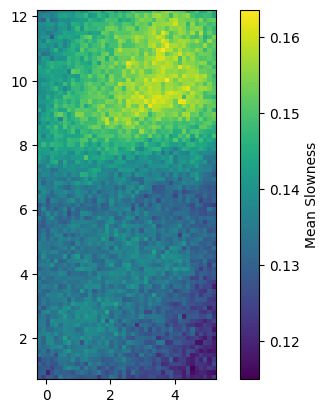

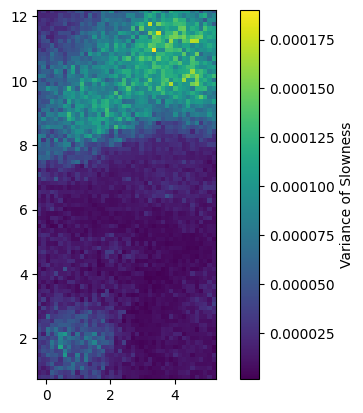

In [ ]:
mean_samples = np.mean(samples_arr, axis=0)
var_samples = np.var(samples_arr, axis=0)

plt.figure()
plt.imshow(mean_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin='lower', cmap=cm.viridis)
plt.colorbar(label='Mean Slowness')

plt.figure()
plt.imshow(var_samples.T, extent=(x[0], x[-1], y[0], y[-1]), origin='lower', cmap=cm.viridis)
plt.colorbar(label='Variance of Slowness')

c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\seaborn\_core\data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)
c:\Users\jeppe\Documents\MEGA\Base\DTU\30760 Inverse Problems and Machine Learning in Earth and Space Physics\nanopinv\.venv\Lib\site-packages\seaborn\_core\data.py:313: UserWarning: Conversion using Arrow PyCapsule Interface failed due to missing PyArrow>=14 dependency, falling back to (deprecated) interchange protocol. We recommend that you install PyArrow>=14.0.0.
  return pd.api.interchange.from_dataframe(data)


<Axes: xlabel='step', ylabel='acceptance_rate'>

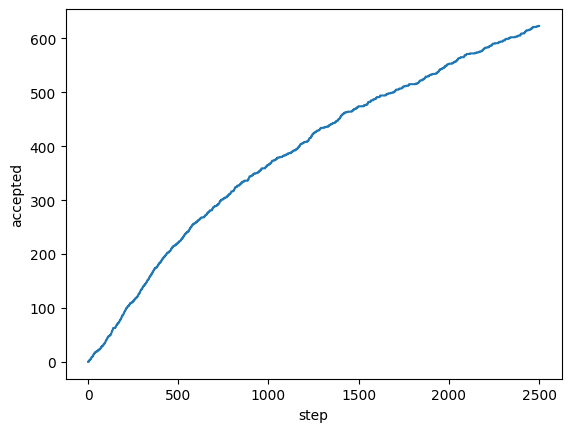

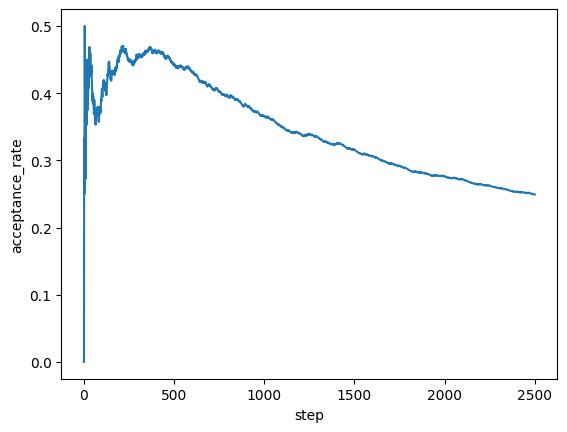

In [ ]:
import polars as pl
df = pl.DataFrame(data)
df

sns.lineplot(data=df, x="step", y="accepted")
plt.figure()
sns.lineplot(data=df, x="step", y="acceptance_rate")

In [ ]:
# import numpy as np#
import skfmm#
from scipy.interpolate import RegularGridInterpolator#

# 1. Define the spatial g# rid
# Note: NumPy arrays are natively (row, column) corresponding to (y,#  x).
x = np.linspace(0, 10,#  101)
y = np.linspace(0, 10# , 101)
dx = x[1]#  - x[0]
dy = y[1]#  - y[0]

# 2. Define the velocity fie# ld V(y, x)
# Using a constant velocity of 2.0 for # simplicity,
# but this can be any spatially va# rying array.
V = np.full((len(y), l# en(x)), 2.0)

# 3. Define Source (S) and Receiver (R) spat# ial coordinates
S = (2.3# , 3.1)  # (x, y)
R = (8.4# , 7.6)  # (x, y)

# 4. Initialize # the level-set (phi)
ph# i = np.ones_like(V)

# Find the discrete grid indices closest # to the source location
ix_s = np.a# rgmin(np.abs(x - S[0]))
iy_s = np.a# rgmin(np.abs(y - S[1]))

# Set the source node to 0 to act as # the boundary condition # T=0
phi[iy_s, ix_s] = 0.0

# 5.#  Run the Fast Marching Method
# dx is passed as [dy, dx] to mat# ch the array dimensions (y, x)
t_field = skfmm.travel_t# ime(phi, speed=V, dx=[dy, dx])

# 6. Interpolate the travel time fie# ld at the exact receiver location
# RegularGridInterpolator expects the ax# es to match the array shape (y, x)
interpolator = RegularGridInterpolator# ((y, x), t_field, method='linear')#

# Evaluate at the receiver R(y, x)
# Wrap in an ar# ray to unpack the single scalar result
t_receiver = i# nterpolator(np.array([R[1], R[0]]))[0]

print(f"Ca# lculated travel time: {t_receiver:.4f}")

# For a constant veloc# ity of 2.0, analytic time is Distance / 2.0
dis# t = np.sqrt((R[0]-S[0])**2 + (R[1]-S[1])**2)
print(f"Analytic travel time:   {dist / 2.0:.4f}")


SyntaxError: invalid syntax. Perhaps you forgot a comma? (505306207.py, line 8)